# Effective Hamiltonian System Example

This notebook compares:
- the compact `system_example` reference model built with `qn_compact=True`
- a fixed-basis effective model built in the zero-field basis at `E=[0,0,0]`, `B=[0,0,1e-5]`

Effective-model structure in this notebook run:
- coherent active states: all `X, J=0` plus `B, J=1, F1=1/2, F=1, P=\pm`
- explicit compact sink states: `X, J=1`, `X, J=2`, `X, J=3`
- parent space for downfolding: the full `184`-state manifold (`64 X + 120 B`)

Important: the compact reference is in a field-dressed compact basis, while the effective model is in a fixed zero-field basis. Sector totals are therefore the cleanest direct comparison.

In [1]:
from __future__ import annotations

import importlib
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

repo_root = next(
    path
    for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (
        path / "examples" / "effective hamiltonian" / "effective_hamiltonian_runtime.py"
    ).exists()
)
helper_dir = repo_root / "examples" / "effective hamiltonian"
if str(helper_dir) not in sys.path:
    sys.path.insert(0, str(helper_dir))

import effective_hamiltonian_runtime as ehr

ehr = importlib.reload(ehr)

np.set_printoptions(precision=6, suppress=True)


In [2]:
E_FIELD = np.array([0.0, 0.0, 50.0])
B_FIELD = np.array([0.0, 0.0, 1e-5])
RABI_RATE = 2.0 * np.pi * 1e6
DETUNING = 0.0
T_EVAL = np.linspace(0.0, 50e-6, 401)

model = ehr.prepare_effective_hamiltonian_model(
    space_generation_electric_field=E_FIELD,
    reference_electric_field=np.array([0.0, 0.0, 0.0]),
    reference_magnetic_field=B_FIELD,
)
effective_bundle = model.effective_bundle(E_FIELD, B_FIELD)
summary = ehr.summarize_static_comparison(model, E_FIELD, B_FIELD)
summary


{'n_full_states': 184,
 'n_active_states': 7,
 'n_effective_states': 10,
 'p_state_labels': ['|X, J = 0, F₁ = 1/2, F = 0, mF = 0, I₁ = 1/2, I₂ = 1/2, P = +, Ω = 0>',
  '|X, J = 0, F₁ = 1/2, F = 1, mF = -1, I₁ = 1/2, I₂ = 1/2, P = +, Ω = 0>',
  '|X, J = 0, F₁ = 1/2, F = 1, mF = 0, I₁ = 1/2, I₂ = 1/2, P = +, Ω = 0>',
  '|X, J = 0, F₁ = 1/2, F = 1, mF = 1, I₁ = 1/2, I₂ = 1/2, P = +, Ω = 0>',
  '|B, J = 1, F₁ = 1/2, F = 1, mF = -1, I₁ = 1/2, I₂ = 1/2, P = -, Ω = 1>',
  '|B, J = 1, F₁ = 1/2, F = 1, mF = 0, I₁ = 1/2, I₂ = 1/2, P = -, Ω = 1>',
  '|B, J = 1, F₁ = 1/2, F = 1, mF = 1, I₁ = 1/2, I₂ = 1/2, P = -, Ω = 1>'],
 'sink_labels': ['X, J=1 sink', 'X, J=2 sink', 'X, J=3 sink'],
 'full_reference_frequency_MHz': -1449.473451648,
 'perturbative_ratio_max': 0.1835284824100087,
 'effective_hermiticity_error': 0.0,
 'sylvester_residual_norm': 5.5612053561445944e-05,
 'spectral_separation_min_MHz': 15.970327822971774,
 'exact_p_like_eigenvalues_MHz': array([   -0.010497,    -0.010497,    -0.010497

In [3]:
def label_rows(qn_list):
    rows = []
    for q in qn_list:
        state = q.largest if hasattr(q, "largest") else q
        rows.append(
            (
                getattr(getattr(state, "electronic_state", None), "name", None),
                getattr(state, "J", None),
                getattr(state, "F1", None),
                getattr(state, "F", None),
                getattr(state, "mF", None),
                getattr(state, "P", None),
                getattr(state, "Omega", None),
            )
        )
    return rows


reference_system, reference_bundle = ehr.build_compact_reference_bundle(
    electric_field=E_FIELD,
    magnetic_field=B_FIELD,
    rabi_rate=RABI_RATE,
    detuning=DETUNING,
)

active_effective_labels = label_rows(model.p_states)
effective_labels = (
    active_effective_labels[:4] + list(model.sink_labels) + active_effective_labels[4:]
)

{
    "reference_labels": label_rows(reference_system.QN),
    "effective_labels": effective_labels,
    "reference_jump_shape": reference_bundle.c_array.shape,
    "effective_jump_shape": effective_bundle.c_array.shape,
}


{'reference_labels': [('X', np.int64(0), 0.5, 0, 0, np.int64(1), 0),
  ('X', np.int64(0), 0.5, 1, -1, np.int64(1), 0),
  ('X', np.int64(0), 0.5, 1, 0, np.int64(1), 0),
  ('X', np.int64(0), 0.5, 1, 1, np.int64(1), 0),
  ('X', np.int64(1), None, None, None, np.int64(-1), 0),
  ('X', np.int64(2), None, None, None, np.int64(1), 0),
  ('X', np.int64(3), None, None, None, np.int64(-1), 0),
  ('B', np.int64(1), 0.5, 1, -1, -1, np.int64(1)),
  ('B', np.int64(1), 0.5, 1, 0, -1, np.int64(1)),
  ('B', np.int64(1), 0.5, 1, 1, -1, np.int64(1))],
 'effective_labels': [('X', np.int64(0), 0.5, 0, 0, np.int64(1), 0),
  ('X', np.int64(0), 0.5, 1, -1, np.int64(1), 0),
  ('X', np.int64(0), 0.5, 1, 0, np.int64(1), 0),
  ('X', np.int64(0), 0.5, 1, 1, np.int64(1), 0),
  'X, J=1 sink',
  'X, J=2 sink',
  'X, J=3 sink',
  ('B', np.int64(1), 0.5, 1, -1, -1, 1),
  ('B', np.int64(1), 0.5, 1, 0, -1, 1),
  ('B', np.int64(1), 0.5, 1, 1, -1, 1)],
 'reference_jump_shape': (18, 10, 10),
 'effective_jump_shape': (0, 10,

## Static `Ez = 100 V/cm` propagation

Both models are propagated at a constant field. The compact reference uses the same setup as `system_example.ipynb`, while the effective model uses prebuilt fixed-basis operators in the zero-field basis.

In [4]:
_, reference_bundle, sol_reference = ehr.solve_static_compact_reference_model(
    electric_field=E_FIELD,
    magnetic_field=B_FIELD,
    rabi_rate=RABI_RATE,
    detuning=DETUNING,
    t_span=(0.0, float(T_EVAL[-1])),
    t_eval=T_EVAL,
)

sol_effective = ehr.solve_static_effective_model(
    model,
    electric_field=E_FIELD,
    magnetic_field=B_FIELD,
    rabi_rate=RABI_RATE,
    detuning=DETUNING,
    t_span=(0.0, float(T_EVAL[-1])),
    t_eval=T_EVAL,
)

rho_reference = ehr.solution_to_density_matrices(
    sol_reference, reference_bundle.h_internal.shape[0]
)
rho_effective = ehr.solution_to_density_matrices(
    sol_effective, model.n_effective_states
)

pop_reference = np.real(np.diagonal(rho_reference, axis1=1, axis2=2))
pop_effective = np.real(np.diagonal(rho_effective, axis1=1, axis2=2))


In [5]:
reference_ground = pop_reference[:, 0:4].sum(axis=1)
effective_ground = pop_effective[:, : len(model.p_ground_indices)].sum(axis=1)

reference_sink = pop_reference[:, 4:7].sum(axis=1)
effective_sink = pop_effective[:, model.sink_positions].sum(axis=1)

reference_excited = pop_reference[:, reference_bundle.excited_indices].sum(axis=1)
effective_excited = pop_effective[:, model.excited_positions].sum(axis=1)

reference_signal = ehr.scattering_signal(
    rho_reference, reference_bundle.jump_rate_operator()
)
effective_signal = ehr.scattering_signal(
    rho_effective, effective_bundle.jump_rate_operator()
)

diagnostics = {
    "perturbative_ratio_max": summary["perturbative_ratio_max"],
    "effective_hermiticity_error": summary["effective_hermiticity_error"],
    "max_sector_ground_diff": float(
        np.max(np.abs(reference_ground - effective_ground))
    ),
    "max_sector_sink_diff": float(np.max(np.abs(reference_sink - effective_sink))),
    "max_sector_excited_diff": float(
        np.max(np.abs(reference_excited - effective_excited))
    ),
    "max_scattering_signal_diff": float(
        np.max(np.abs(reference_signal - effective_signal))
    ),
    "final_trace_reference": float(np.trace(rho_reference[-1]).real),
    "final_trace_effective": float(np.trace(rho_effective[-1]).real),
    "effective_active_eigenvalues_MHz": summary["effective_eigenvalues_MHz"],
    "exact_p_like_eigenvalues_MHz": summary["exact_p_like_eigenvalues_MHz"],
}
diagnostics


{'perturbative_ratio_max': 0.1835284824100087,
 'effective_hermiticity_error': 0.0,
 'max_sector_ground_diff': 0.3552005757497415,
 'max_sector_sink_diff': 0.35455000446225343,
 'max_sector_excited_diff': 0.05650618483243408,
 'max_scattering_signal_diff': 554005.4649421687,
 'final_trace_reference': 0.9999999999999994,
 'final_trace_effective': 1.0000000000000007,
 'effective_active_eigenvalues_MHz': array([-0.010497, -0.010497, -0.010497,  0.002803,  0.025976,  0.793898,
         0.793907]),
 'exact_p_like_eigenvalues_MHz': array([   -0.010497,    -0.010497,    -0.010497,     0.002803,
            0.020332,   563.705178, 81457.65679 ])}

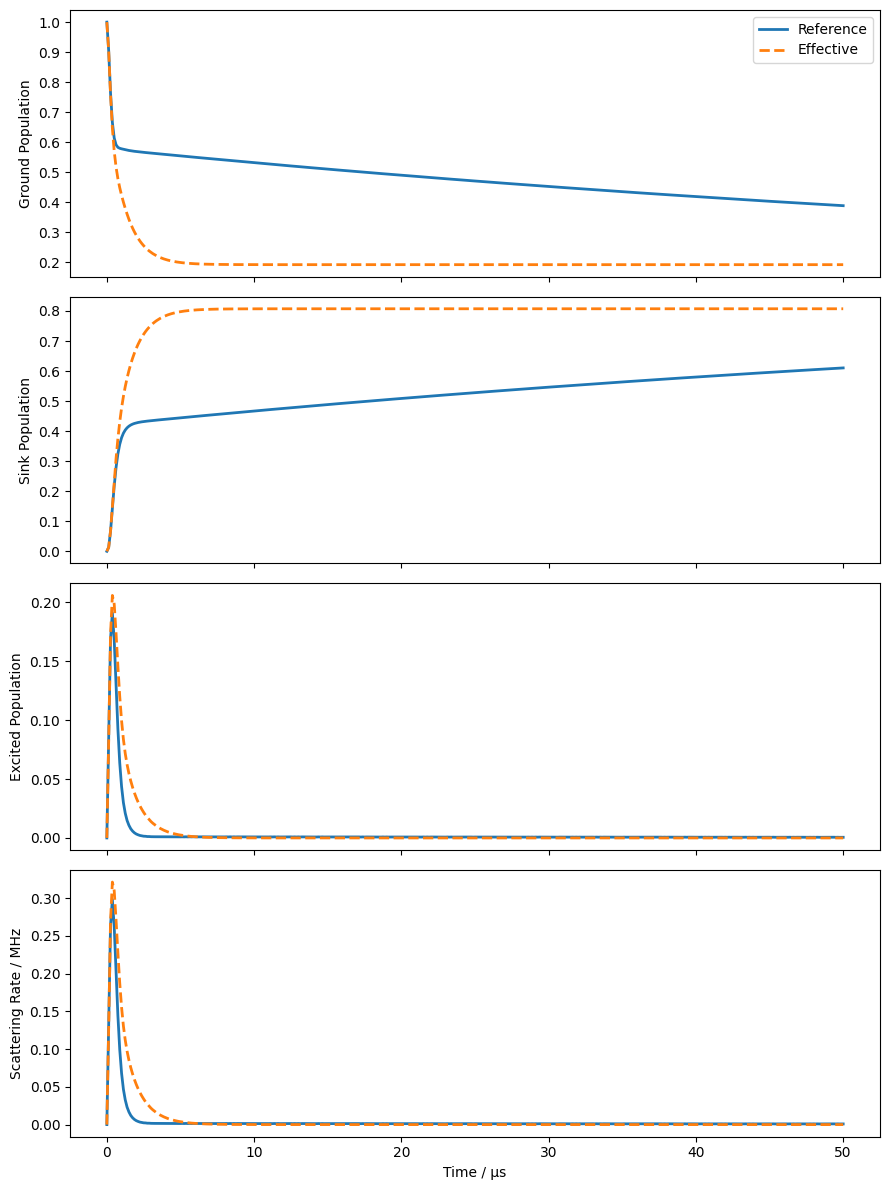

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(9, 12), sharex=True)

axes[0].plot(T_EVAL * 1e6, reference_ground, label="Reference", lw=2)
axes[0].plot(T_EVAL * 1e6, effective_ground, label="Effective", lw=2, ls="--")
axes[0].set_ylabel("Ground Population")
axes[0].legend()

axes[1].plot(T_EVAL * 1e6, reference_sink, label="Reference", lw=2)
axes[1].plot(T_EVAL * 1e6, effective_sink, label="Effective", lw=2, ls="--")
axes[1].set_ylabel("Sink Population")

axes[2].plot(T_EVAL * 1e6, reference_excited, label="Reference", lw=2)
axes[2].plot(T_EVAL * 1e6, effective_excited, label="Effective", lw=2, ls="--")
axes[2].set_ylabel("Excited Population")

axes[3].plot(
    T_EVAL * 1e6, reference_signal / (2.0 * np.pi * 1e6), label="Reference", lw=2
)
axes[3].plot(
    T_EVAL * 1e6,
    effective_signal / (2.0 * np.pi * 1e6),
    label="Effective",
    lw=2,
    ls="--",
)
axes[3].set_ylabel("Scattering Rate / MHz")
axes[3].set_xlabel("Time / µs")

fig.tight_layout()


## Notes

- The compact reference basis is field dressed, so individual diagonal populations are not expected to match the fixed-basis effective model state-by-state.
- The main checks here are perturbative validity, sector totals, and overall driven/decay behavior.
- If the sector-level mismatch is still too large, the next thing to inspect is the operator dressing and the treatment of the compact sink channels.